Stability parameter r_x = 0.09801
Stability parameter r_y = 0.09801


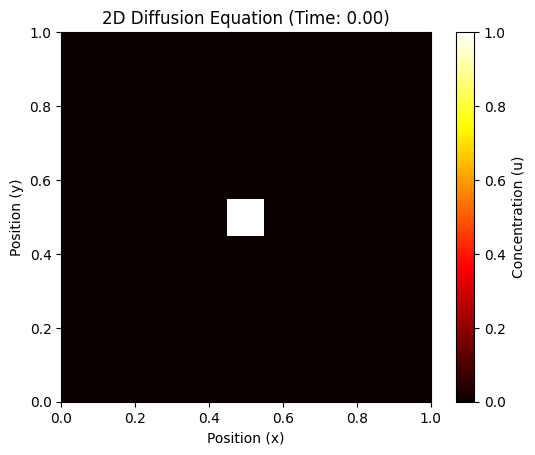

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Parameters ---
L = 1.0  # Length of the domain in x-direction
Ly = 1.0 # Length of the domain in y-direction
T = 0.5  # Total simulation time
Nx = 100 # Number of spatial points in x
Ny = 100 # Number of spatial points in y
Nt = 500 # Number of time steps
D = 0.01 # Diffusion coefficient

# --- Discretization ---
dx = L / (Nx - 1) # Spatial step size in x
dy = Ly / (Ny - 1) # Spatial step size in y
dt = T / Nt      # Time step size

# Stability criterion for explicit method: dt <= 1 / (2*D * (1/dx^2 + 1/dy^2))
# For simplicity, assuming dx=dy, then dt <= dx^2 / (4*D)
# If this condition is not met, the solution may become unstable.
r_x = D * dt / (dx**2)
r_y = D * dt / (dy**2)

print(f"Stability parameter r_x = {r_x}")
print(f"Stability parameter r_y = {r_y}")
if r_x + r_y > 0.5: # More rigorous: dt <= 1 / (2*D * (1/dx^2 + 1/dy^2)) implies r_x + r_y <= 0.5
    print("Warning: r_x + r_y > 0.5, the explicit method might be unstable. Consider reducing dt or increasing dx/dy.")

# --- Initial Condition ---
x = np.linspace(0, L, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)
u = np.zeros((Nx, Ny))

# Example initial condition: Gaussian peak in the middle
# sigma_x = 0.05
# sigma_y = 0.05
# u = np.exp(-((X - L/2)**2 / (2 * sigma_x**2) + (Y - Ly/2)**2 / (2 * sigma_y**2)))

# Example initial condition: square pulse in the middle
start_x = int(Nx/2 - Nx/20)
end_x = int(Nx/2 + Nx/20)
start_y = int(Ny/2 - Ny/20)
end_y = int(Ny/2 + Ny/20)
u[start_x:end_x, start_y:end_y] = 1.0

# --- Simulation ---
history = [u.copy()] # Store the solution at each time step

for n in range(Nt):
    u_new = np.copy(u)
    # Apply finite difference scheme for 2D diffusion
    # u_new[i,j] = u[i,j] + D*dt * ( (u[i+1,j] - 2*u[i,j] + u[i-1,j])/dx^2 + (u[i,j+1] - 2*u[i,j] + u[i,j-1])/dy^2 )
    # simplified with r_x and r_y
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + \
                        r_x * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) + \
                        r_y * (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])

    # Boundary Conditions (Neumann: no flux at boundaries, i.e., du/dx = 0)
    # This is implicitly handled by not updating the boundary points if we use the scheme from 1 to Nx-1, 1 to Ny-1
    # For Dirichlet boundary conditions (e.g., u=0 at boundaries):
    # u_new[0, :] = 0
    # u_new[-1, :] = 0
    # u_new[:, 0] = 0
    # u_new[:, -1] = 0

    u = u_new
    history.append(u.copy())

# --- Visualization ---
fig, ax = plt.subplots()
im = ax.imshow(history[0].T, origin='lower', extent=[0, L, 0, Ly], cmap='hot', vmin=0, vmax=1.0)
ax.set_xlabel("Position (x)")
ax.set_ylabel("Position (y)")
ax.set_title("2D Diffusion Equation")
plt.colorbar(im, ax=ax, label="Concentration (u)")

def animate(i):
    im.set_array(history[i].T)
    ax.set_title(f"2D Diffusion Equation (Time: {i*dt:.2f})")
    return im,

anim = animation.FuncAnimation(fig, animate, frames=Nt, interval=50, blit=True)

plt.show()

# To save the animation as a GIF (requires imagemagick or ffmpeg)
# anim.save('diffusion_2d.gif', writer='pillow', fps=20)


# Task
Define the exogenous and endogenous variables for a Structural Causal Model (SCM) of the 2D diffusion PDE, specifically identifying 'u' (concentration), 'x' (spatial coordinate), 'y' (spatial coordinate), 't' (time), and 'D' (diffusion coefficient).

## Identify Variables for SCM

### Subtask:
Define the exogenous and endogenous variables that would constitute the Structural Causal Model for the 2D diffusion PDE. This includes the concentration 'u', spatial coordinates 'x' and 'y', time 't', and the diffusion coefficient 'D'.


```markdown
## Structural Causal Model (SCM) for 2D Diffusion PDE: Exogenous and Endogenous Variables

In the context of a Structural Causal Model (SCM):

*   **Exogenous Variables** are variables whose causes are external to the model. They are determined by factors not explained or modeled within the system. These variables are considered 'inputs' to the system or parameters that do not change based on the system's internal dynamics.

*   **Endogenous Variables** are variables whose causes are explained or determined within the model itself. Their values are outcomes of the causal relationships defined within the system. These variables are considered 'outputs' or states of the system that evolve based on internal mechanisms.
```

```markdown
### Identifying Variables for the 2D Diffusion PDE

Given the variables: 'u' (concentration), 'x' (spatial coordinate), 'y' (spatial coordinate), 't' (time), and 'D' (diffusion coefficient).

#### Exogenous Variables:

1.  **'x' (spatial coordinate)**: Exogenous.
    *   **Explanation**: The spatial coordinates `x` and `y` define the domain over which the diffusion process occurs. They are fixed, independent dimensions that do not change as a result of the diffusion process itself. They are external parameters that set up the problem's geometry.

2.  **'y' (spatial coordinate)**: Exogenous.
    *   **Explanation**: Similar to `x`, `y` is a fixed, independent spatial dimension. Its value does not depend on the concentration `u` or any other process within the diffusion equation.

3.  **'t' (time)**: Exogenous.
    *   **Explanation**: Time `t` is an independent variable that progresses steadily and is not influenced by the diffusion process. It serves as a parameter defining the temporal evolution of the system, but its passage is external to the internal dynamics being modeled.

4.  **'D' (diffusion coefficient)**: Exogenous.
    *   **Explanation**: The diffusion coefficient `D` is a material property that quantifies how quickly a substance diffuses. It is typically assumed to be constant or determined by external factors (like temperature or material composition) that are not part of the diffusion SCM. It influences `u`, but `u` does not influence `D` within this model.

#### Endogenous Variables:

1.  **'u' (concentration)**: Endogenous.
    *   **Explanation**: The concentration `u` is the primary variable whose evolution is described by the 2D diffusion PDE. Its value at any given point in space and time is directly caused by the initial conditions, boundary conditions, and the diffusion process itself, which is governed by `D`, `x`, `y`, and `t`. The PDE explicitly defines how `u` changes based on these other variables and its own spatial derivatives.
```

## Define Causal Relationships

### Subtask:
Explain the causal links between the identified variables, reflecting how changes in one variable influence another according to the underlying physics described by the diffusion equation. This will involve describing how the concentration 'u' at a given point and time is influenced by its past state and the concentrations of neighboring points, mediated by the diffusion coefficient.


### Causal Relationships in the 2D Diffusion Equation

The 2D diffusion equation describes how a concentration (or similar quantity like temperature or probability density) `u` spreads over a 2D spatial domain over time. The causal links between the identified variables can be understood as follows:

1.  **Influence of Past State and Neighboring Points on `u(x, y, t)`**:
    The concentration `u` at a specific spatial location `(x, y)` and time `t` is directly and causally influenced by:
    *   Its own concentration at the immediately preceding time step, `u(x, y, t - dt)`.
    *   The concentrations of its immediate neighboring points in space at the current or preceding time step. Specifically, in an explicit finite difference scheme, `u(x, y, t)` is influenced by `u(x+dx, y, t-dt)`, `u(x-dx, y, t-dt)`, `u(x, y+dy, t-dt)`, and `u(x, y-dy, t-dt)`. This reflects the physical principle that diffusion is a local process where substances move from areas of higher concentration to areas of lower concentration through random motion.

2.  **Role of the Diffusion Coefficient `D`**:
    The diffusion coefficient `D` is a critical parameter that *mediates* these causal influences. It quantifies the rate at which `u` spreads. A higher `D` means that a given concentration difference between a point and its neighbors will lead to a faster and stronger transfer of `u`. Conversely, a smaller `D` indicates slower diffusion. Essentially, `D` determines the *strength* of the causal link between the concentration gradients and the rate of change of `u`.

3.  **Nature of `x`, `y`, and `t` as Contextual Variables**:
    The variables `x`, `y`, and `t` (spatial coordinates and time) are typically considered *exogenous* in the context of the diffusion process itself. They define the framework within which the phenomenon occurs but are not direct causes of the change in `u` in the same way `D` or neighboring `u` values are. Instead, they act as conditions or indices. They specify *where* and *when* a particular concentration `u` is observed and *over what domain* the diffusion process unfolds. Changes in `x`, `y`, or `t` do not *cause* `u` to change, rather `u` *is a function of* `x`, `y`, and `t` as it evolves according to the physical laws of diffusion.

4.  **Summary: The 2D Diffusion PDE**:
    These relationships are mathematically encapsulated by the 2D diffusion Partial Differential Equation (PDE):

    $$\frac{\partial u}{\partial t} = D \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

    This equation explicitly states the causal links:
    *   The **local change in concentration over time** (`∂u/∂t`) is the *effect*.
    *   The **local spatial curvature** (Laplacian, `∂²u/∂x² + ∂²u/∂y²`), which represents the net difference between a point's concentration and its neighbors, is the *cause*.
    *   The **diffusion coefficient `D`** acts as a constant of proportionality, scaling the effect of the spatial curvature. It directly determines how strongly and rapidly the spatial differences in `u` translate into temporal changes in `u`. Thus, the PDE clearly shows that the temporal evolution of concentration `u` at any point is causally driven by the spatial distribution of `u` in its vicinity, with `D` dictating the intensity of this causal influence.

## Final Task

### Subtask:
Provide a conceptual summary of the Structural Causal Model for the 2D diffusion equation, explaining how the identified variables and their causal relationships form the SCM.


## Summary:

### Data Analysis Key Findings

*   **Variable Classification**:
    *   **Exogenous Variables**: `x` (spatial coordinate), `y` (spatial coordinate), `t` (time), and `D` (diffusion coefficient) were identified as exogenous. These variables are external to the model, defining the spatial-temporal domain and material properties, and are not influenced by the diffusion process itself.
    *   **Endogenous Variable**: `u` (concentration) was identified as endogenous. Its value at any point in space and time is determined by the internal dynamics described by the 2D diffusion equation, dependent on the exogenous variables and its own spatial derivatives.
*   **Causal Influence on Concentration (`u`)**: The concentration `u` at a specific point `(x, y)` and time `t` is causally influenced by its concentration at the immediate preceding time step and the concentrations of its immediate spatial neighbors. This reflects the local and time-dependent nature of diffusion.
*   **Role of Diffusion Coefficient (`D`)**: The diffusion coefficient `D` acts as a mediator, quantifying the rate and strength of the causal influence. A higher `D` leads to a faster and stronger transfer of `u` based on concentration differences.
*   **Contextual Role of `x`, `y`, `t`**: Spatial coordinates `x`, `y` and time `t` are contextual variables; they define the framework and indices for the diffusion process but do not directly cause changes in `u` in the same way `D` or neighboring `u` values do.
*   **Causal Relationships in PDE**: The 2D diffusion equation, $\frac{\partial u}{\partial t} = D \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$, formally encapsulates these relationships: the local change in concentration over time ($\frac{\partial u}{\partial t}$) is the effect, the local spatial curvature (Laplacian, representing concentration differences) is the cause, and `D` acts as the constant of proportionality scaling this causal influence.

### Insights or Next Steps

*   The defined SCM for the 2D diffusion equation provides a clear framework for understanding directional causal relationships within the system, separating parameters that drive the process from the outcomes that are generated.
*   This SCM can be utilized to analyze the impact of interventions, such as changing the diffusion coefficient `D` or initial concentration profiles, on the evolution of `u` without implicitly assuming a causal direction.


### SCM Relationship to the Simulation Code

The 2D diffusion PDE simulation code directly implements the relationships defined in the Structural Causal Model:

#### Exogenous Variables in Code:

*   **`x` and `y` (Spatial Coordinates)**:
    *   In the code: Defined by `x = np.linspace(0, L, Nx)` and `y = np.linspace(0, Ly, Ny)`. These arrays represent the fixed spatial grid over which `u` is calculated. `X, Y = np.meshgrid(x, y)` creates the 2D coordinate system.
    *   SCM Connection: They are set at the beginning and do not change, acting as fixed 'inputs' to define the domain.

*   **`t` (Time)**:
    *   In the code: Represented by the `for n in range(Nt)` loop, where `n` is the time step index, and `dt = T / Nt` is the constant time increment. The animation's title `(Time: {i*dt:.2f})` explicitly shows time progression.
    *   SCM Connection: Time progresses independently and causally influences `u`'s evolution but is not influenced by `u`.

*   **`D` (Diffusion Coefficient)**:
    *   In the code: Defined as a constant `D = 0.01`. It's then incorporated into the stability parameters `r_x` and `r_y` (`r_x = D * dt / (dx**2)`, `r_y = D * dt / (dy**2)`).
    *   SCM Connection: `D` is a fixed material property that scales the rate of diffusion. It's an external parameter influencing the system's dynamics, not an outcome of them.

#### Endogenous Variable in Code:

*   **`u` (Concentration)**:
    *   In the code: Initialized as a 2D NumPy array `u = np.zeros((Nx, Ny))` and then given an initial condition (e.g., a square pulse). Within the simulation loop, `u` is repeatedly updated (`u = u_new`). The `history` list stores `u`'s state at each time step.
    *   SCM Connection: `u` is the primary variable whose values are determined by the internal mechanics of the diffusion process (initial conditions, boundary conditions, and the PDE itself). Its evolution is the 'output' of the model.

#### Causal Relationships in Code:

The core causal relationship—how `u` changes over time due to spatial differences—is encapsulated in the finite difference update equation within the simulation loop:

```python
u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + \
                    r_x * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) + \
                    r_y * (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2])
```

*   **`u`'s dependence on its past state**: The term `u[1:-1, 1:-1]` on the right-hand side represents the concentration at the *previous* time step `t-dt` at the current point `(x, y)`.
*   **`u`'s dependence on neighboring points**: The terms `u[2:, 1:-1]`, `u[:-2, 1:-1]`, `u[1:-1, 2:]`, and `u[1:-1, :-2]` represent the concentrations of the immediate spatial neighbors of the point `(x, y)` at the previous time step. The differences (e.g., `u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]`) approximate the second spatial derivatives (Laplacian), which are the *cause* of `u`'s change.
*   **`D` as a mediator**: `r_x` and `r_y` (which contain `D` and `dt`) act as scaling factors for these spatial differences. A larger `D` directly leads to a larger update in `u_new`, demonstrating its causal role in determining the *rate* and *strength* of diffusion.

In essence, the simulation code numerically solves the PDE, making the causal flow from `D`, `x`, `y`, `t`, and the local spatial gradients of `u` to the temporal evolution of `u` explicitly visible.